# Exploratory analysis of the sorghum disease-screen data

This notebook provides focused exploratory data analysis of the released tables used in the manuscript. It examines sample sizes, candidate frequencies, assessment frequencies, disease categories, and the composition of the repeatedly identified candidates. Its two plots are simple diagnostic views for scientific review; final manuscript figures are generated separately by `generate_figures.py`.

Run the notebook from `reproducibility/code`. It reads the supplied data from this package.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial"],
    "font.size": 9.0,
    "axes.titlesize": 9.0,
    "axes.titleweight": "bold",
    "axes.labelsize": 9.0,
    "xtick.labelsize": 8.5,
    "ytick.labelsize": 8.5,
    "legend.fontsize": 8.5,
})

CODE_DIR = Path.cwd().resolve()
PACKAGE_ROOT = Path(os.environ.get("ATLAS_PACKAGE_ROOT", CODE_DIR.parents[1])).resolve()
DATA_DIR = PACKAGE_ROOT / "reproducibility" / "data"

paths = {
    "Accessions or lines across independent screens": DATA_DIR / "analysis_inputs" / "Recurrence_Analysis_Matrix_Anonymous.csv",
    "Direct disease comparisons": DATA_DIR / "analysis_inputs" / "Fixed_Margin_Comparison_Blocks.csv",
    "Study criteria met by repeatedly identified candidates": DATA_DIR / "analysis_inputs" / "Recurrent_Candidate_Qualifying_Memberships.csv",
    "Repeatedly identified candidates": DATA_DIR / "aggregate_data" / "Recurrent_Candidate_Registry.csv",
    "Analyses with multiple response endpoints": DATA_DIR / "figure_source_data" / "Figure_S1_Pareto_source_data.csv",
}

tables = {name: pd.read_csv(path) for name, path in paths.items()}
file_overview = pd.DataFrame(
    [
        {"Table": name, "Rows": len(frame), "Columns": len(frame.columns)}
        for name, frame in tables.items()
    ]
)
display(file_overview)

qualifying_records = tables["Study criteria met by repeatedly identified candidates"]
unique_candidate_screen_links = qualifying_records[["normalized_accession_or_line_id", "evidence_set_id"]].drop_duplicates()
display(pd.DataFrame({
    "Quantity": ["Observations in which a candidate met a study criterion", "Distinct candidate and independent screen combinations"],
    "Count": [len(qualifying_records), len(unique_candidate_screen_links)],
}))


,Table,Rows,Columns
0,Accessions or lines across independent screens,5163,3
1,Direct disease comparisons,5,6
2,Study criteria met by repeatedly identified ca...,401,11
3,Repeatedly identified candidates,171,17
4,Analyses with multiple response endpoints,26,6


,Quantity,Count
0,Observations in which a candidate met a study ...,401
1,Distinct candidate and independent screen comb...,349


## Repeated candidate identification

We summarized how often each anonymous accession or line was assessed, whether it met the documented criterion, and the number identified as candidates in each independent screen.


In [2]:
recurrence = tables["Accessions or lines across independent screens"].copy()
recurrence["candidate_selected"] = pd.to_numeric(
    recurrence["candidate_selected"], errors="raise"
).astype(int)

by_accession = recurrence.groupby("analysis_identity_id").agg(
    number_of_sets=("evidence_set_id", "nunique"),
    number_of_candidate_findings=("candidate_selected", "sum"),
)
by_set = recurrence.groupby("evidence_set_id").agg(
    accessions_or_lines_assessed=("analysis_identity_id", "nunique"),
    candidates=("candidate_selected", "sum"),
)

recurrence_overview = pd.DataFrame(
    {
        "Quantity": [
            "Independent screens",
            "Anonymous accessions or lines",
            "Accessions or lines assessed in at least two independent screens",
            "Candidates assessed in one independent screen only",
        ],
        "Count": [
            recurrence["evidence_set_id"].nunique(),
            recurrence["analysis_identity_id"].nunique(),
            by_accession["number_of_sets"].ge(2).sum(),
            (
                by_accession["number_of_sets"].eq(1)
                & by_accession["number_of_candidate_findings"].gt(0)
            ).sum(),
        ],
    }
)
display(recurrence_overview)
display(
    by_set.describe()
    .loc[["min", "50%", "max"]]
    .rename_axis("Summary")
    .rename(
        columns={
            "accessions_or_lines_assessed": "Accessions or lines assessed",
            "candidates": "Candidates",
        }
    )
)


,Quantity,Count
0,Independent screens,34
1,Anonymous accessions or lines,3655
2,Accessions or lines assessed in at least two i...,1154
3,Candidates assessed in one independent screen ...,1335


,Accessions or lines assessed,Candidates
Summary,,
min,1.0,0.0
50%,68.0,19.0
max,1240.0,835.0


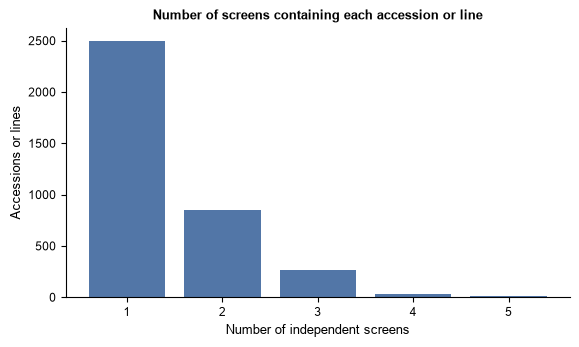

In [3]:
assessment_counts = by_accession["number_of_sets"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.bar(assessment_counts.index.astype(str), assessment_counts.values, color="#5276A7")
ax.set_xlabel("Number of independent screens")
ax.set_ylabel("Accessions or lines")
ax.set_title("Number of screens containing each accession or line")
ax.spines[["top", "right"]].set_visible(False)
plt.show()


## Composition of the repeatedly identified candidates

The supplementary candidate table contains the 171 accessions or lines identified in more than one independent screen. The summaries below show whether repeated findings involved the same disease or different diseases and the number of screens contributing to each candidate.


In [4]:
registry = tables["Repeatedly identified candidates"].copy()
registry_summary = (
    registry["recurrence_pattern"]
    .replace(
        {
            "same_disease_recurrence": "Same disease",
            "cross_disease_only": "Different diseases only",
        }
    )
    .value_counts()
    .rename_axis("Pattern")
    .reset_index(name="Candidates")
)
set_count_summary = (
    pd.to_numeric(registry["qualifying_evidence_set_n"], errors="raise")
    .value_counts()
    .sort_index()
    .rename_axis("Number of independent screens")
    .reset_index(name="Candidates")
)
display(registry_summary)
display(set_count_summary)


,Pattern,Candidates
0,Different diseases only,93
1,Same disease,78


,Number of independent screens,Candidates
0,2,164
1,3,7


In [5]:
disease_counts = (
    registry["disease_categories"]
    .fillna("")
    .str.split(r"\s*\|\s*", regex=True)
    .explode()
    .loc[lambda values: values.ne("")]
    .value_counts()
    .rename_axis("Disease category")
    .reset_index(name="Repeatedly identified candidates")
)
disease_counts["Disease category"] = (
    disease_counts["Disease category"].str.replace("_", " ", regex=False).str.title()
)
display(disease_counts.head(12))


,Disease category,Repeatedly identified candidates
0,Anthracnose,164
1,Head Smut,43
2,Rust,29
3,Grain Mold,21
4,Head Smut Seedling Spot,14
5,Head Smut P5,11
6,Zonate Leaf Spot,9
7,Head Smut P6,9
8,Downy Mildew,3


## Direct comparisons of responses to multiple diseases

Five comparisons assessed the same accessions or lines for two or three diseases. These descriptive views show the number assessed and the observed number classified favorably for multiple diseases in each comparison.


,Comparison,Accessions or lines assessed,Favorable for multiple diseases
0,"Puerto Rico, 2017 to 2018",108,25
1,"Sorghum mini-core, 2019",224,76
2,Senegal collection (Cuevas et al. 2018),129,13
3,Converted lines,48,1
4,U.S. accessions,47,0


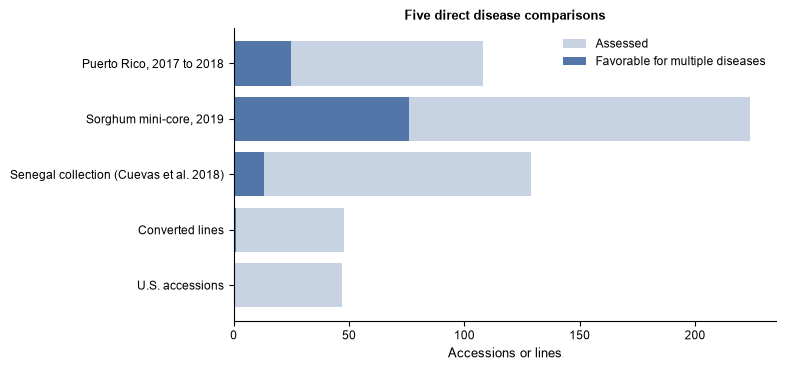

In [6]:
comparisons = tables["Direct disease comparisons"].copy()
comparison_view = comparisons[
    ["comparison_label", "complete_case_n", "observed_multidisease_n"]
].rename(
    columns={
        "comparison_label": "Comparison",
        "complete_case_n": "Accessions or lines assessed",
        "observed_multidisease_n": "Favorable for multiple diseases",
    }
)
display(comparison_view)

fig, ax = plt.subplots(figsize=(7.0, 3.8))
y = np.arange(len(comparison_view))
ax.barh(y, comparison_view["Accessions or lines assessed"], color="#C7D3E3", label="Assessed")
ax.barh(
    y,
    comparison_view["Favorable for multiple diseases"],
    color="#5276A7",
    label="Favorable for multiple diseases",
)
ax.set_yticks(y, comparison_view["Comparison"])
ax.invert_yaxis()
ax.set_xlabel("Accessions or lines")
ax.set_title("Five direct disease comparisons")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.show()


## Secondary comparison across multiple endpoints

Across 26 analyses, we compared the number assessed with the number on the Pareto front. An accession or line was on the Pareto front when no other accession or line performed at least as well on every endpoint and better on at least one. Notebook 02 presents the analyses of repeated candidate identification and direct disease overlap.


In [7]:
multiple_endpoints = tables["Analyses with multiple response endpoints"].copy()
endpoint_overview = pd.DataFrame(
    {
        "Quantity": [
            "Analyses",
            "Sum of counts on the Pareto front across analyses",
            "Smallest number assessed in one analysis",
            "Largest number assessed in one analysis",
        ],
        "Count": [
            len(multiple_endpoints),
            multiple_endpoints["Accessions or lines on the Pareto front (n)"].sum(),
            multiple_endpoints["Accessions or lines assessed (n)"].min(),
            multiple_endpoints["Accessions or lines assessed (n)"].max(),
        ],
    }
)
display(endpoint_overview)


,Quantity,Count
0,Analyses,26
1,Sum of counts on the Pareto front across analyses,439
2,Smallest number assessed in one analysis,14
3,Largest number assessed in one analysis,328
